In [1]:
import numpy as np

import sasmodels
import sasmodels.core
import sasmodels.data
import sasmodels.bumps_model

import sasdata

from sasdata.dataloader.loader import Loader
from sasmodels.data import load_data
from sasmodels.data import plot_theory

import bumps
import bumps.fitters
import bumps.names
import bumps.fitproblem

import os

In [2]:
"""
import matplotlib.pyplot and set custom default settings for plots
"""
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import matplotlib.pyplot as plt

plt.rc('font', size=14) 
plt.rc('axes', titlesize=16)
plt.rc('axes', labelsize=16)
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('legend', fontsize=14)
plt.rc('legend', title_fontsize=14)
plt.rc('figure', titlesize=18)
plt.rc("figure", figsize=(5,5))
plt.rc("lines", linewidth=3)

In [3]:
sasdata.__version__

'0.11.0'

In [4]:
sasmodels.__version__

'1.0.12'

* avoid underscore _ in a folder name !

In [5]:
#filename='./data-examples/e6_10mM.dat'
#filename='./data-examples/SWING-mn1-00169{00028}_AzInt_Px_28.dat'

#filename="./data-examples/Agm.dat"

filename="./Soleil-April-26/Agm.dat"

* subtraction from empty file

In [6]:
fileempty="./Soleil-April-26/empty.dat"

* manual adjustment of the coefficient before subtraction empty file

total number of data points:  1207


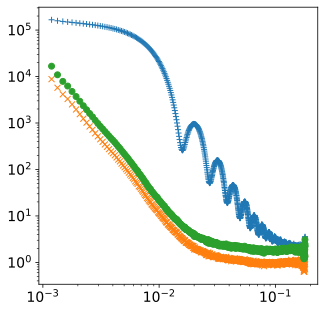

In [7]:
#number of lines in the header
skipheader=48 

# Using loadtxt 
data_np = np.loadtxt(filename, skiprows=skipheader)

empty_np = np.loadtxt(fileempty, skiprows=skipheader)

total_data_number=data_np.shape[0] #total number of data points in the file
print('total number of data points: ',total_data_number)

coeffempty=1.9

plt.loglog(data_np[:,0], data_np[:,1], '+')
plt.loglog(empty_np[:,0], empty_np[:,1], 'x')
plt.loglog(empty_np[:,0], coeffempty*empty_np[:,1], 'o')




total number of data points:  1207
after skip at low and large q values: 1007
after slicing: 504


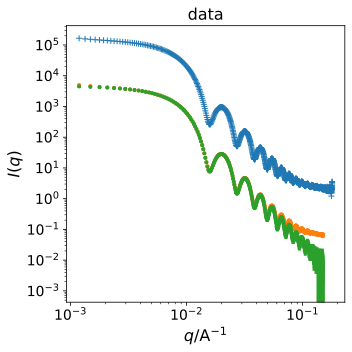

In [8]:
#number of lines in the header
skipheader=48 

# Using loadtxt to load data
data_np = np.loadtxt(filename, skiprows=skipheader)

total_data_number=data_np.shape[0] #total number of data points in the file
print('total number of data points: ',total_data_number)

plt.loglog(data_np[:,0], data_np[:,1], '+')

#number of points to skip at low q values
skipmin=0
data_np = np.loadtxt(filename, skiprows=skipheader+skipmin)

# number of data point to skip at the end
skipmax=200 # MUST BE 0. TP_mn1 doesn't have 620 points to skip!
number_of_data=total_data_number-skipmax-skipmin

print('after skip at low and large q values:', number_of_data)

slicing_step=2 # step of slicing 

# rescaling of intensity values
# TP UE soft matter 2026
# scaling factor from SWING to Cu-SAXS to be in cm-1
rescale=0.03

# new error bars: 10 % of intensity values
coeff=0.1

data = sasmodels.data.Data1D(x=data_np[0:number_of_data:slicing_step,0], 
                             y=rescale*data_np[0:number_of_data:slicing_step,1], 
                             dy=rescale*coeff*data_np[0:number_of_data:slicing_step,1])

# datasub incorporates the subtraction of empty file
datasub= sasmodels.data.Data1D(x=data_np[0:number_of_data:slicing_step,0], 
                             y=rescale*(data_np[0:number_of_data:slicing_step,1]-coeffempty*empty_np[0:number_of_data:slicing_step,1]), 
                             dy=rescale*coeff*data_np[0:number_of_data:slicing_step,1])

number_of_data_new=data.x.shape[0]
print('after slicing:', number_of_data_new)

sasmodels.data.plot_data(data)
sasmodels.data.plot_data(datasub)

* use data=datasub only if subtraction is OK

In [9]:
data=datasub

In [10]:
newfilename=filename[:-4]+"_new.dat" # data 

with open(newfilename, "w") as f:
    f.write("raw data file is:"+filename+"\n")
    f.write("number of data points: \t"+str(number_of_data_new)+"\n")

with open(newfilename, "a") as fa:
    for i in range(0,number_of_data_new):
        line_to_write=str(data.x[i])+"\t"+str(data.y[i])+"\t"+str(data.dy[i])+"\n"
        fa.write(line_to_write)

In [11]:

kernel = sasmodels.core.load_model("core_shell_sphere")
params = {} # default parameters for now
model = sasmodels.bumps_model.Model(kernel, **params)
experiment = sasmodels.bumps_model.Experiment(data=data, model=model)

In [12]:
kernel.info.parameters.defaults

{'scale': 1,
 'background': 0.001,
 'radius': 60.0,
 'thickness': 10.0,
 'sld_core': 1.0,
 'sld_shell': 2.0,
 'sld_solvent': 3.0,
 'up_frac_i': 0.0,
 'up_frac_f': 0.0,
 'up_theta': 90.0,
 'up_phi': 0.0,
 'sld_core_M0': 0.0,
 'sld_core_mtheta': 0.0,
 'sld_core_mphi': 0.0,
 'sld_shell_M0': 0.0,
 'sld_shell_mtheta': 0.0,
 'sld_shell_mphi': 0.0,
 'sld_solvent_M0': 0.0,
 'sld_solvent_mtheta': 0.0,
 'sld_solvent_mphi': 0.0}

In [13]:
sld_gold=125
sld_silver=77.9
sld_water=9.47
sld_toluene=8.4

# for a test with a density slightly less in the shell ...
sld_silver_shell=75


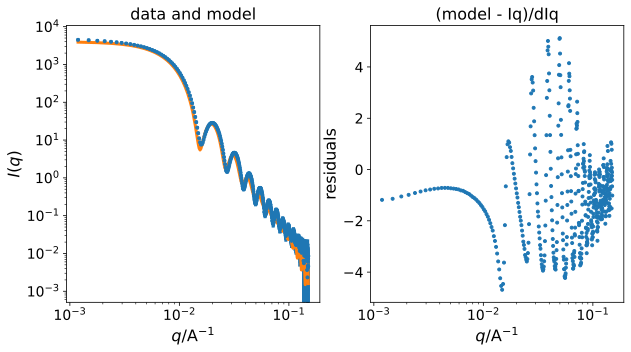

In [14]:
kernel = sasmodels.core.load_model("core_shell_sphere")

params = {
    "radius": 290,
    "radius_pd_type": 'gaussian', 
    "radius_pd": 0.06, 
    "radius_pd_n": 8, 
    "radius_pd_nsigma": 4, 
    "thickness": 0.,              
    "thickness_pd_type": 'gaussian', 
    "thickness_pd": 0.04,          
    "thickness_pd_n": 20, 
    "thickness_pd_nsigma": 4, 
    "sld_core": sld_silver,
    "sld_shell": sld_silver_shell,         
    "sld_solvent": sld_water,
    "background": 0.0005,
    "scale": 0.00008
}

model = sasmodels.bumps_model.Model(model=kernel, **params)
experiment = sasmodels.bumps_model.Experiment(data=data, model=model)

plt.figure(figsize=(10,5))

experiment.plot()

c:\Users\IMPÉROR\CloudStation\dev-Lan\.venv\Lib\site-packages\sasmodels\kernelcl.py:469: RepeatedKernelRetrieval: Kernel 'core_shell_sphere_Iq' has been retrieved more than once. Each retrieval creates a new, independent kernel, at possibly considerable expense. To avoid the expense, reuse the retrieved kernel instance. To avoid this warning, use cl.Kernel(prg, name).
  functions = [getattr(program, k) for k in names]
c:\Users\IMPÉROR\CloudStation\dev-Lan\.venv\Lib\site-packages\sasmodels\kernelcl.py:469: RepeatedKernelRetrieval: Kernel 'core_shell_sphere_Iqxy' has been retrieved more than once. Each retrieval creates a new, independent kernel, at possibly considerable expense. To avoid the expense, reuse the retrieved kernel instance. To avoid this warning, use cl.Kernel(prg, name).
  functions = [getattr(program, k) for k in names]
c:\Users\IMPÉROR\CloudStation\dev-Lan\.venv\Lib\site-packages\sasmodels\kernelcl.py:469: RepeatedKernelRetrieval: Kernel 'core_shell_sphere_Imagnetic' has

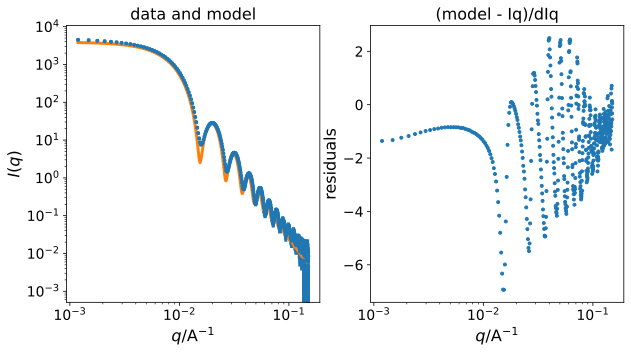

In [15]:
kernel = sasmodels.core.load_model("core_shell_sphere")

params = {
    "radius": 290,
    "radius_pd_type": 'gaussian', 
    "radius_pd": 0.04, 
    "radius_pd_n": 8, 
    "radius_pd_nsigma": 4, 
    "thickness": 0.,              
    "thickness_pd_type": 'gaussian', 
    "thickness_pd": 0.04,          
    "thickness_pd_n": 20, 
    "thickness_pd_nsigma": 4, 
    "sld_core": sld_silver,
    "sld_shell": sld_silver_shell,         
    "sld_solvent": sld_water,
    "background": 0.0005,
    "scale": 0.00008
}

model = sasmodels.bumps_model.Model(model=kernel, **params)
experiment = sasmodels.bumps_model.Experiment(data=data, model=model)

plt.figure(figsize=(10,5))
experiment.plot()

step 1 cost 4.2577(94)
                              background ....|.....     0.0005 in [1e-07, 0.001]
                                  radius ......|...        290 in [270, 300]
                               radius_pd .......|..       0.04 in [0, 0.05]
                                   scale .....|....      8e-05 in [5e-05, 0.0001]
step 8 cost 1.1473(94) [final]
                              background .........|      0.001 in [1e-07, 0.001]
                                  radius ....|.....    283.304 in [270, 300]
                               radius_pd ........|.  0.0401737 in [0, 0.05]
                                   scale .........| 9.74771e-05 in [5e-05, 0.0001]
time 72 milliseconds
Fit results for problem: χ² = 1.1473(94)
=== Uncertainty from curvature:     name   value(unc.) ===
                              background   0.00100(54)    
                                  radius   283.30(19)     
                               radius_pd   0.04017(58)    
               

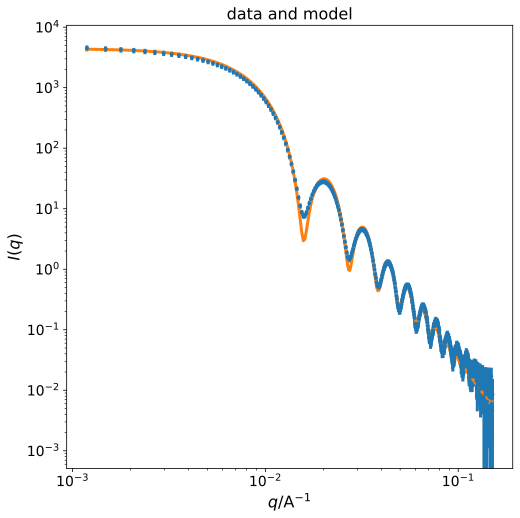

In [16]:
model = sasmodels.bumps_model.Model(model=kernel, **params)

model.scale.range(0.00005, 0.00010)      
model.background.range(0.0000001, 0.001)   
model.radius.range(270, 300)          
model.radius_pd.range(0.0, 0.05)    
#model.thickness.range(0, 20)  
#model.sld_shell.range(70,90)      
#model.thickness_pd.range(0.0, 0.5)   

experiment = sasmodels.bumps_model.Experiment(data=data, model=model)

problem = bumps.fitproblem.FitProblem(experiment)

results = bumps.fitters.fit(problem, 
                            method='lm', 
                            steps=20,   
                            ftol=1.5e-06, 
                            xtol=1.5e-06, 
                            verbose=True)

plt.figure(figsize=(8,8))
print(problem.summarize())
print(model.state())
print(f"Chi-Squared: {problem.chisq()}")
sasmodels.data.plot_theory(data,experiment.Iq_calc)

In [17]:
print(model.state())
print(problem.summarize())
print(problem.chisq())

{'scale': 9.747711092524428e-05, 'background': 0.001, 'radius': 283.30353965341027, 'radius_pd': 0.040173746463483054, 'radius_pd_n': 8.0, 'radius_pd_nsigma': 4.0, 'thickness': 0.0, 'thickness_pd': 0.04, 'thickness_pd_n': 20.0, 'thickness_pd_nsigma': 4.0, 'sld_core': 77.9, 'sld_shell': 75.0, 'sld_solvent': 9.47, 'up_frac_i': 0.0, 'up_frac_f': 0.0, 'up_theta': 90.0, 'up_phi': 0.0, 'sld_core_M0': 0.0, 'sld_core_mtheta': 0.0, 'sld_core_mphi': 0.0, 'sld_shell_M0': 0.0, 'sld_shell_mtheta': 0.0, 'sld_shell_mphi': 0.0, 'sld_solvent_M0': 0.0, 'sld_solvent_mtheta': 0.0, 'sld_solvent_mphi': 0.0, 'radius_pd_type': 'gaussian', 'thickness_pd_type': 'gaussian'}
                              background .........|      0.001 in [1e-07, 0.001]
                                  radius ....|.....    283.304 in [270, 300]
                               radius_pd ........|.  0.0401737 in [0, 0.05]
                                   scale .........| 9.74771e-05 in [5e-05, 0.0001]
1.1472766605713522


In [18]:
# value of R after fiting
R_fit=model.radius.value

# value of Thickness after fiting (Replaces L_fit)
T_fit=model.thickness.value

In [19]:
fitfilename=filename[:-4]+"_fit.dat" # fit 

with open(fitfilename, "w") as f:
    f.write("raw data file is:"+filename+"\n")
    f.write("number of data points: \t"+str(number_of_data_new)+"\n")

with open(fitfilename, "a") as fa:
    for i in range(0,number_of_data_new-1):
        line_to_write=str(data.x[i])+"\t"+str(experiment.Iq_calc[i])+"\n"
        fa.write(line_to_write)

In [20]:
results.x

array([1.00000000e-03, 2.83303540e+02, 4.01737465e-02, 9.74771109e-05])

In [21]:
results.dx

array([5.39748326e-04, 1.90900383e-01, 5.75595932e-04, 7.05722160e-07])

In [22]:
# value of core radius after fitting
R_fit = model.radius.value

# value of shell thickness after fitting
T_fit = model.thickness.value

1.1472766605713522


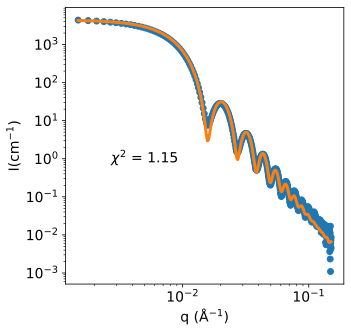

In [23]:
data_final = np.loadtxt(newfilename, skiprows=3)

fit_final = np.loadtxt(fitfilename, skiprows=3)

plt.loglog(data_final[:,0], data_final[:,1], 'o')
plt.loglog(fit_final[:,0], fit_final[:,1])
plt.xlabel('q '+r'(Å$^{-1}$)',fontsize=14)
plt.ylabel('I'+r'(cm$^{-1}$)',fontsize=14)
plt.text(0.005,0.8,r'$\chi^2$ = '+f"{problem.chisq():.2f}",fontsize=14,horizontalalignment='center')
print(problem.chisq())